<a href="https://colab.research.google.com/github/Peihan-Cui/CS175-AI-vs-Human-Code-Detection/blob/main/CS175GemmaFinetuned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="OSS-forge/HumanVsAICode",
    filename="python_dataset.jsonl",
    repo_type="dataset"
)

print("File downloaded to:", file_path)

File downloaded to: /root/.cache/huggingface/hub/datasets--OSS-forge--HumanVsAICode/snapshots/03cac5dd2096c8901cb7a74e2ecbd26624ada497/python_dataset.jsonl


In [3]:
import json

data = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

In [4]:
import pandas as pd

python_df = pd.DataFrame(data)

code_cols = ['human_code', 'chatgpt_code', 'dsc_code', 'qwen_code']
python_df = python_df.melt(id_vars=['docstring'], value_vars=code_cols,
                  var_name='writer_type', value_name='code')

python_df['writer'] = python_df['writer_type'].map({
    'human_code': 'human',
    'chatgpt_code': 'gpt',
    'dsc_code': 'dsc',
    'qwen_code': 'qwen'
})
python_df['is_ai'] = (python_df['writer'] != 'human').astype(int)

python_df = python_df[['docstring', 'code', 'writer', 'is_ai']]

In [6]:
sample_df = (
    python_df
    .groupby("writer", group_keys=False)
    .apply(lambda x: x.sample(
        frac=0.50 if x.name == "human" else (0.5 / 3),
        random_state=42
    ))
    .sample(n=5000, random_state=1)
    .reset_index(drop=True)
)

/tmp/ipykernel_2919/2574907849.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [7]:
sample_df['writer'].value_counts()

,count
writer,
human,2505
qwen,851
dsc,835
gpt,809


## Gemma model with 1b params

In [3]:
!pip install -U transformers accelerate datasets peft trl bitsandbytes huggingface_hub

  Using cached trl-0.29.0-py3-none-any.whl.metadata (11 kB)
  Using cached huggingface_hub-1.7.1-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 118.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 133.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 119.4 MB/s eta 0:00:00
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.2
    Uninstalling hf-xet-1.3.2:
      Successfully uninstalled hf-xet-1.3.2
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.20.3
    Uninstalling tokenizers-0.20.3:
      

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, GemmaTokenizer, Gemma3ForCausalLM

Will use a zero-shot prompt when training. With 1000 samples, Gemma overwhelmingly guessed AI for few-shot prompts and was more balanced for one-shot and zero-shot prompts.
Using a one-shot prompt can introduce bias depending on the label class of the example, so I will use a zero-shot prompt. Besides, the objective of fine-tuning is for it to find patterns in the code independently.

In [8]:
import json

def format_example(row):
    label = "AI" if row["is_ai"] else "Human"

    reasoning = (
        "Explanation referencing specific elements of the code such as comments, docstring, formatting, and nomenclature."
        if label == "AI"
        else "Explanation referencing specific elements of the code such as comments, docstring, formatting, and nomenclature."
    )

    response = json.dumps({
        "result": label,
        "reasoning": reasoning
    })

    prompt = f"""Determine whether the following Python code was written by a human or generated by AI.

    Code:
    {row['code'][:1000]}

    Respond in JSON with keys 'result' and 'reasoning'.
    Follow these example models of Code and Completion.

    Example 1:
    Code:
    def f(x): return x+1

    Completion:
    {{'result': 'Human', 'reasoning': 'No comments, docstrings, or type annotations.'}}

    Example 2:
    Code:
    def f(x: int) -> int:
        \"\"\"Increments the input x by 1\"\"\"
        return x+1 # incrementing

    Completion:
    {{'result': 'Human', 'reasoning': 'Frequently uses comments, docstrings, and type annotations'}}
    """

    return {
        "prompt": prompt,
        "completion": response
    }

# Convert each row to {prompt + response} format
all_data = sample_df.apply(format_example, axis=1).tolist()

In [9]:
import random

random.seed(42)
random.shuffle(all_data)  # shuffle before split

split_idx = int(0.8 * len(all_data))  # 80% for training

train_data = all_data[:split_idx]
eval_data = all_data[split_idx:]

In [9]:
len(train_data)

4000

In [10]:
len(eval_data)

1000

In [11]:
train_data[:5]

[{'prompt': 'Determine whether the following Python code was written by a human or generated by AI.\n\n    Code:\n    def config_resolution_order(is_dependency_model, own_project_config, in_model_config, active_project_config):\n    if is_dependency_model:\n        return own_project_config or in_model_config or active_project_config\n    else:\n        return active_project_config or in_model_config\n\n\n    Respond in JSON with keys \'result\' and \'reasoning\'.\n    Follow these example models of Code and Completion.\n\n    Example 1:\n    Code:\n    def f(x): return x+1\n\n    Completion:\n    {\'result\': \'Human\', \'reasoning\': \'No comments, docstrings, or type annotations.\'}\n\n    Example 2:\n    Code:\n    def f(x: int) -> int:\n        """Increments the input x by 1"""\n        return x+1 # incrementing\n\n    Completion:\n    {\'result\': \'Human\', \'reasoning\': \'Frequently uses comments, docstrings, and type annotations\'}\n    ',
  'completion': '{"result": "AI", "r

In [12]:
from datasets import Dataset, DatasetDict

train_dataset = Dataset.from_list(train_data)
eval_dataset = Dataset.from_list(eval_data)

dataset_dict = DatasetDict({
    "train": train_dataset,
    "eval": eval_dataset
})

In [13]:
def merge_prompt_completion(example):
    return {"text": example["prompt"] + example["completion"]}

dataset_dict = dataset_dict.map(merge_prompt_completion)

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [14]:
dataset_dict["train"][0]
# {"text": "<prompt + completion>"}

{'prompt': 'Determine whether the following Python code was written by a human or generated by AI.\n\n    Code:\n    def config_resolution_order(is_dependency_model, own_project_config, in_model_config, active_project_config):\n    if is_dependency_model:\n        return own_project_config or in_model_config or active_project_config\n    else:\n        return active_project_config or in_model_config\n\n\n    Respond in JSON with keys \'result\' and \'reasoning\'.\n    Follow these example models of Code and Completion.\n\n    Example 1:\n    Code:\n    def f(x): return x+1\n\n    Completion:\n    {\'result\': \'Human\', \'reasoning\': \'No comments, docstrings, or type annotations.\'}\n\n    Example 2:\n    Code:\n    def f(x: int) -> int:\n        """Increments the input x by 1"""\n        return x+1 # incrementing\n\n    Completion:\n    {\'result\': \'Human\', \'reasoning\': \'Frequently uses comments, docstrings, and type annotations\'}\n    ',
 'completion': '{"result": "AI", "rea

In [12]:
gemma_model_id = "google/gemma-3-1b-it"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

gemma_model = Gemma3ForCausalLM.from_pretrained(
    "google/gemma-3-1b-it",
    quantization_config=quantization_config,
    device_map="auto"
)

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

In [16]:
gemma_tokenizer = AutoTokenizer.from_pretrained(gemma_model_id)
gemma_tokenizer.pad_token = gemma_tokenizer.eos_token

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

### Fine-tuning Gemma using PEFT (Parameter-Efficient Fine-Tuning), which only modifies a small subset of params

In [17]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj","v_proj"],  # typical for causal LM
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

gemma_model = get_peft_model(gemma_model, lora_config)
gemma_model.print_trainable_parameters()

trainable params: 745,472 || all params: 1,000,631,424 || trainable%: 0.0745


### Fine-tune the model using [TRL SFTTrainer](https://huggingface.co/docs/trl/en/sft_trainer)

In [18]:
from trl import SFTConfig

sft_config = SFTConfig(
    output_dir="./gemma-code-detector",
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=3,
    max_length=1024,
    fp16=False,
    bf16=False,
    dataset_text_field="text",
    completion_only_loss=True
)

In [19]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=gemma_model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=gemma_tokenizer,
)

Adding EOS to train dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [20]:
dataset_dict['train']['text']

Column(['Determine whether the following Python code was written by a human or generated by AI.\n\n    Code:\n    def config_resolution_order(is_dependency_model, own_project_config, in_model_config, active_project_config):\n    if is_dependency_model:\n        return own_project_config or in_model_config or active_project_config\n    else:\n        return active_project_config or in_model_config\n\n\n    Respond in JSON with keys \'result\' and \'reasoning\'.\n    Follow these example models of Code and Completion.\n\n    Example 1:\n    Code:\n    def f(x): return x+1\n\n    Completion:\n    {\'result\': \'Human\', \'reasoning\': \'No comments, docstrings, or type annotations.\'}\n\n    Example 2:\n    Code:\n    def f(x: int) -> int:\n        """Increments the input x by 1"""\n        return x+1 # incrementing\n\n    Completion:\n    {\'result\': \'Human\', \'reasoning\': \'Frequently uses comments, docstrings, and type annotations\'}\n    {"result": "AI", "reasoning": "Explanation 

In [21]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'pad_token_id': 1}.


Step,Training Loss
10,2.207605
20,0.447079
30,0.035738
40,0.022719
50,0.016513
60,0.013938
70,0.015930
80,0.013279
90,0.010182
100,0.010740


TrainOutput(global_step=375, training_loss=0.0808459024031957, metrics={'train_runtime': 841.4197, 'train_samples_per_second': 14.262, 'train_steps_per_second': 0.446, 'total_flos': 2.3472410591563776e+16, 'train_loss': 0.0808459024031957})

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [122]:
trainer.save_model("/content/drive/MyDrive/gemma-code-detector")

### Loading fine-tuned model and running inference on it

In [13]:
from peft import PeftModel

model = PeftModel.from_pretrained(
    gemma_model,
    "mhaiskaa/gemma-finetuned-human-ai-code-classification"
)

In [14]:
tokenizer = AutoTokenizer.from_pretrained(
    "mhaiskaa/gemma-finetuned-human-ai-code-classification"
)

tokenizer_config.json:   0%|          | 0.00/716 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

### Running Inference on trained model

In [15]:
remaining_df = python_df.merge(
    sample_df,
    on=["docstring", "code", "writer", "is_ai"],
    how="left",
    indicator=True
)

remaining_df = remaining_df[remaining_df["_merge"] == "left_only"].drop(columns="_merge")

sample_inference_df = (
    remaining_df
    .groupby("is_ai", group_keys=False)
    .apply(lambda x: x.sample(10, random_state=42))
    .reset_index(drop=True)
)

/tmp/ipykernel_2919/2345405400.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(10, random_state=42))


In [16]:
sample_inference_df['is_ai'].value_counts()

,count
is_ai,
0,10
1,10


In [17]:
import json

example1 = json.dumps({
    "result": "Human",
    "reasoning": "No docstrings or type annotations. Any comments that are present may have incorrect punctuation, spelling, or grammar. Code might also be very long"
})

example2 = json.dumps({
    "result": "AI",
    "reasoning": "Frequently uses comments, docstrings, and type annotations. Comments have perfect punctuation, spelling, and grammar"
})

skeleton = json.dumps({"result": "Human/AI", "reasoning": "..."})

In [18]:
def format_example(row):
    prompt = f"""Respond in JSON with keys 'result' (that only contains values 'Human' or 'AI') and 'reasoning' (which explains why you classified the 'result' as 'Human' or 'AI').
    Here are some example models of Code and Completion.

    Human Example:
    Code:
    def _build_url(cls, request, path=None, **changes):
        query_strings = []
        def add_query(key):
            query_strings.append('='.format(key, queries[key])
                                 if queries[key] != '' else key)
        def del_query(key):
            queries.pop(key, None)
        if 'head' in queries:
            add_query('head')
            del_query('head')
        if 'limit' in queries:
            add_query('limit')
            del_query('limit')
        for key in sorted(queries):
            add_query(key)
        scheme = cls._get_forwarded(request, 'proto') or request.url.scheme
        host = cls._get_forwarded(request, 'host') or request.host
        forwarded_path = cls._get_forwarded(request, 'path')
        path = path if path is not None else request.path
        query = '?' + '&'.join(query_strings) if query_strings else ''
        url = ''.format(scheme, host, forwarded_path, path, query)
        return url

    Completion:
    {example1}

    AI Example:
    Code:
    def _build_url(cls, request, path=None, **changes):
      # Parse the original URL
      parsed_url = urlparse(request.url)
        # Get the original queries
        original_queries = dict(qc.split(\"=\") for qc in parsed_url.query.split(\"&\")

        # Update the original queries with the changes
          for key, value in changes.items():
              if value is False:
                # Remove the key if it exists
                original_queries.pop(key, None)
              elif value is not None:
                # Update the key with the new value
                original_queries[key] = value
                # Build the new URL
                new_url = urlunparse((
                  parsed_url.scheme,
                  parsed_url.netloc,
                  path or parsed_url.path,
                  \"\",  # This should be empty for the queries
                  urlencode(original_queries, doseq=True),  # Encode the queries\
                  \"\"  # Fragment is not used
                ))


    Completion:
    {example2}

    The generic template of the Completion is: {skeleton}.

    Think about the patterns that distinguish AI-generated from Human-written code.
    Code to classify:
    {row["code"][:500]}
"""
    return prompt

In [19]:
prompts = sample_inference_df.apply(format_example, axis=1).tolist()

In [20]:
import torch

model.eval()

results = []

for prompt in prompts:
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=150,
        temperature=0.0,
        do_sample=False
    )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    results.append(decoded)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [21]:
results

['Respond in JSON with keys \'result\' (that only contains values \'Human\' or \'AI\') and \'reasoning\' (which explains why you classified the \'result\' as \'Human\' or \'AI\').\n    Here are some example models of Code and Completion.\n\n    Human Example:\n    Code:\n    def _build_url(cls, request, path=None, **changes):\n        query_strings = []\n        def add_query(key):\n            query_strings.append(\'=\'.format(key, queries[key])\n                                 if queries[key] != \'\' else key)\n        def del_query(key):\n            queries.pop(key, None)\n        if \'head\' in queries:\n            add_query(\'head\')\n            del_query(\'head\')\n        if \'limit\' in queries:\n            add_query(\'limit\')\n            del_query(\'limit\')\n        for key in sorted(queries):\n            add_query(key)\n        scheme = cls._get_forwarded(request, \'proto\') or request.url.scheme\n        host = cls._get_forwarded(request, \'host\') or request.host\n

In [22]:
import json
import re

import json

def extract_model_result(output: str, marker: str = "Code to classify:"):
    """
    Extract the model JSON by looking for the "result" key after a marker.
    Returns a dict with 'result' and 'reasoning' or None.
    """
    try:
        # Only consider text after the last marker
        if marker in output:
            output = output.split(marker)[-1]

        # Find the first occurrence of '"result"' or "'result'"
        idx = output.find('"result"')
        if idx == -1:
            idx = output.find("'result'")
        if idx == -1:
            return None

        # Slice from "result" to the end
        json_str = '{' + output[idx:]

        # Try to parse the JSON from this string
        # Sometimes there is extra trailing text, so remove everything after the last closing brace
        last_brace = json_str.rfind("}")
        if last_brace != -1:
            json_str = json_str[:last_brace+1]

        return json.loads(json_str)
    except Exception as e:
        print("Failed to parse JSON:", e)
        return None

json_results = [extract_model_result(r) for r in results]

Failed to parse JSON: Extra data: line 1 column 87 (char 86)


In [23]:
# Define a mapping from model outputs to canonical labels
label_map = {"Human": "Human", "AI": "AI", "\"Human\"": "Human", "\"AI\"": "AI", "human": "Human", "ai": "AI"}

predictions = []
for r in json_results:
    if r is None:
        predictions.append("Unknown")
    else:
        # Map the result to Human/AI, or Unknown if unexpected
        print(r.get('result'))
        predictions.append(label_map.get(r.get("result"), "Unknown"))

Human
AI
AI
AI
AI
AI
AI
AI
AI
AI
AI
AI
Human
AI
AI
result
AI


In [24]:
predictions

['Human',
 'AI',
 'AI',
 'Unknown',
 'AI',
 'AI',
 'AI',
 'AI',
 'AI',
 'AI',
 'AI',
 'AI',
 'AI',
 'Human',
 'Unknown',
 'AI',
 'AI',
 'Unknown',
 'Unknown',
 'AI']

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

In [26]:
sample_inference_df.head()

,docstring,code,writer,is_ai
0,Returns a list of time zones to which a phone ...,def time_zones_for_geographical_number(numobj)...,human,0
1,Turns python dicts in to valid body-queries or...,"def _dict_to_query(data, params=True, base_que...",human,0
2,Read a command from the user line by line.\n\n...,def read_command(self):\n reader = self...,human,0
3,Executes `func` in a separate greenlet in the ...,"def execute_greenlet_async(func, *args, **kwar...",human,0
4,Returns sequence of poller configurations\n ...,def poller_configurations(self):\n conf...,human,0


In [27]:
true_labels_bool = sample_inference_df["is_ai"].tolist()
# predictions already contains mapped results like ["Human", "AI", "Unknown"]

In [28]:
true_labels_bool

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

In [29]:
# Define a mapping from model outputs to canonical labels
label_map = {"Human": "Human", "AI": "AI", "human": "Human", "ai": "AI", 0: "Human", 1: "AI"}

true_labels = []
for r in true_labels_bool:
    if r is None:
        true_labels.append("Unknown")
    else:
        # Map the result to Human/AI, or Unknown if unexpected
        true_labels.append(label_map[r])

In [30]:
true_labels

['Human',
 'Human',
 'Human',
 'Human',
 'Human',
 'Human',
 'Human',
 'Human',
 'Human',
 'Human',
 'AI',
 'AI',
 'AI',
 'AI',
 'AI',
 'AI',
 'AI',
 'AI',
 'AI',
 'AI']

In [31]:
mask = [p != "Unknown" for p in predictions]
filtered_acc = accuracy_score(
    [t for t, m in zip(true_labels, mask) if m],
    [p for p, m in zip(predictions, mask) if m]
)
print(f"Accuracy (excluding Unknowns): {filtered_acc}")

Accuracy (excluding Unknowns): 0.4375


In [32]:
cm = confusion_matrix(true_labels, predictions, labels=["Human", "AI", "Unknown"])
cm_df = pd.DataFrame(cm, index=["Human", "AI", "Unknown"], columns=["Human", "AI", "Unknown"])

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

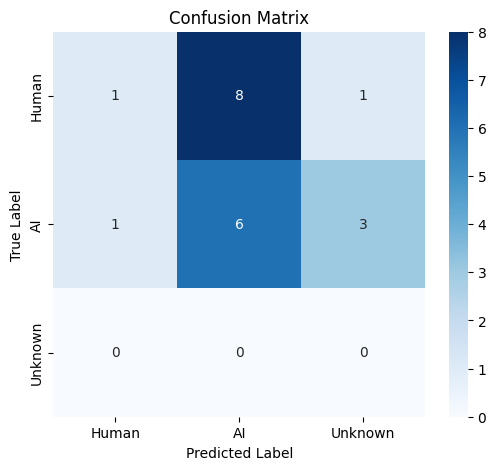

In [34]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()